# Whisker-Pole Contact Detection — Dataset Creation

This notebook builds a binary classification dataset from a video and frame-range annotations.

**Inputs:**
- Video file (`output.mp4`)
- `contact_new3.csv` — frame ranges where whisker contacts the pole (label = 1)
- `no_cont.csv` — frame ranges with no contact (label = 0)

**Outputs:**
- `train.pkl` — 80 % of labelled frames (images + labels + frame numbers)
- `test.pkl` — 20 % of labelled frames (images + labels + frame numbers)

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the Create Dataset folder is on the path so we can import utils
DATASET_DIR = os.path.dirname(os.path.abspath("__file__"))
if DATASET_DIR not in sys.path:
    sys.path.insert(0, DATASET_DIR)

from utils import (
    build_label_dataframe,
    extract_frames,
    split_dataset,
    save_pkl,
    load_pkl,
)

## 1 — Configuration

Set the paths to your video and annotation CSVs here.  
Optionally set a `RESIZE` tuple `(width, height)` to shrink frames (speeds up training, saves disk).

In [2]:
# ========================  EDIT THESE PATHS  ========================

# Path to the video (WSL path to Windows files via /mnt/c/)
VIDEO_PATH = "/mnt/c/Users/wanglab/Desktop/Club Like Endings/102725_1/output.mp4"

# Path to the contact frame-range CSV
CONTACT_CSV = "/mnt/c/Users/wanglab/Desktop/Club Like Endings/102725_1/contact_new3.csv"

# Path to the no-contact frame-range CSV
NO_CONTACT_CSV = "/mnt/c/Users/wanglab/Desktop/Club Like Endings/102725_1/no_cont.csv"

# ========================  OUTPUT SETTINGS  =========================

# Where to save the pickle files
OUTPUT_DIR = os.path.join(DATASET_DIR, "data")

# Resize frames to (width, height). Set to None to keep original resolution.
RESIZE = (224, 224)

# Train / test split ratio
TEST_SIZE = 0.20
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: /home/wanglab/Deep-Learning/Contact Classification/Create Dataset/data


## 2 — Build Label DataFrame

Parse the CSV files to create a master DataFrame mapping every annotated frame to its label.

In [3]:
label_df = build_label_dataframe(CONTACT_CSV, NO_CONTACT_CSV)

print(f"Total labelled frames : {len(label_df):,}")
print(f"  Contact (1)         : {(label_df['label'] == 1).sum():,}")
print(f"  No contact (0)      : {(label_df['label'] == 0).sum():,}")
print()
label_df.head(10)

Total labelled frames : 21,908
  Contact (1)         : 18,602
  No contact (0)      : 3,306



,frame,label
0,7263,0
1,7264,0
2,7265,0
3,7266,0
4,7267,0
5,7268,0
6,7269,0
7,7270,0
8,7271,0
9,7272,0


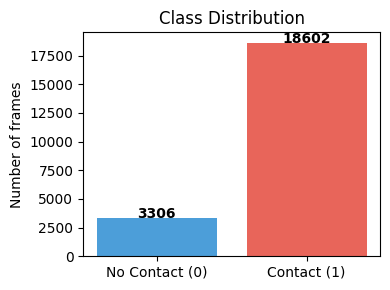

In [4]:
# Visualise class distribution
counts = label_df["label"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["No Contact (0)", "Contact (1)"], counts.values, color=["#4c9ed9", "#e8655a"])
ax.set_ylabel("Number of frames")
ax.set_title("Class Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 3 — Extract Frames from Video

Read only the annotated frames from the video (much faster than decoding every frame).

In [5]:
images = extract_frames(
    video_path=VIDEO_PATH,
    frame_numbers=label_df["frame"].values,
    resize=RESIZE,
)

print(f"\nExtracted {len(images):,} frames")
if images:
    sample_frame = next(iter(images.values()))
    print(f"Frame shape: {sample_frame.shape}  dtype: {sample_frame.dtype}")

Extracting frames: 100%|██████████| 21908/21908 [14:48<00:00, 24.66it/s]


Extracted 21,908 frames
Frame shape: (224, 224, 3)  dtype: uint8


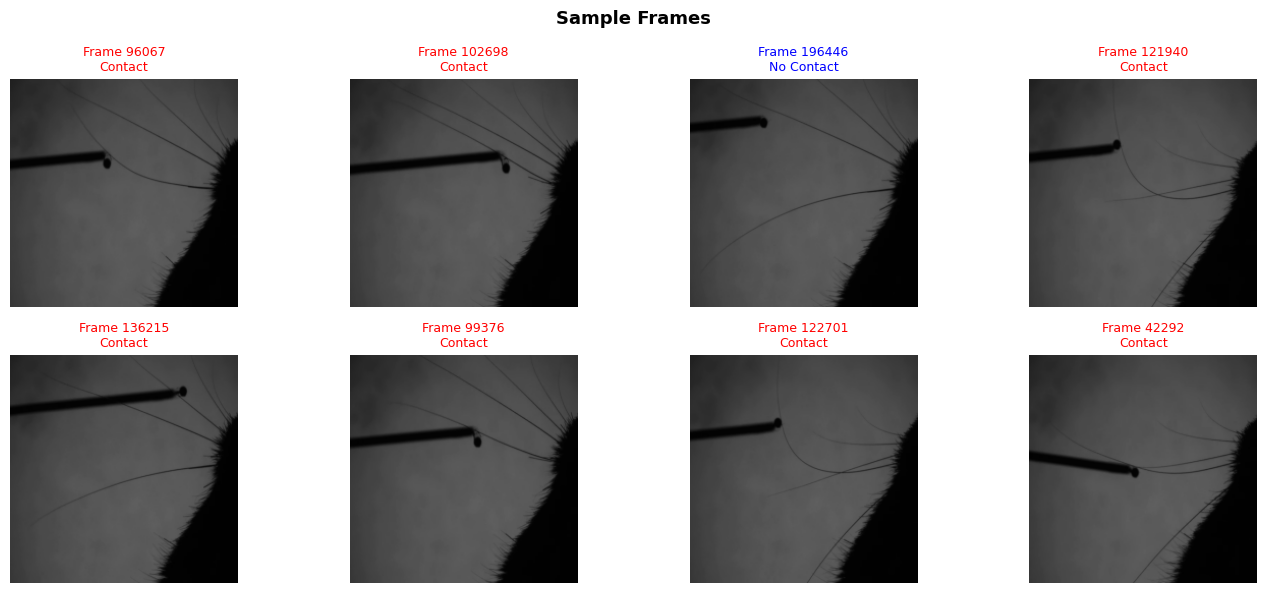

In [6]:
# Preview a few sample frames
sample_indices = label_df.sample(n=min(8, len(label_df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_indices.iterrows()):
    fnum = row["frame"]
    lbl = row["label"]
    if fnum in images:
        ax.imshow(images[fnum])
        ax.set_title(f"Frame {fnum}\n{'Contact' if lbl else 'No Contact'}",
                     color="red" if lbl else "blue", fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Frames", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 — Train / Test Split & Save to Pickle

Stratified 80:20 split to preserve class balance, then save to `.pkl` files.

In [7]:
train_data, test_data = split_dataset(
    label_df, images,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Train set : {len(train_data['labels']):,} frames  "
      f"(contact: {(train_data['labels']==1).sum():,}, "
      f"no-contact: {(train_data['labels']==0).sum():,})")
print(f"Test  set : {len(test_data['labels']):,} frames  "
      f"(contact: {(test_data['labels']==1).sum():,}, "
      f"no-contact: {(test_data['labels']==0).sum():,})")

Train set : 17,526 frames  (contact: 14,881, no-contact: 2,645)
Test  set : 4,382 frames  (contact: 3,721, no-contact: 661)


In [8]:
# Save pickle files
save_pkl(train_data, os.path.join(OUTPUT_DIR, "train.pkl"))
save_pkl(test_data,  os.path.join(OUTPUT_DIR, "test.pkl"))

Saved /home/wanglab/Deep-Learning/Contact Classification/Create Dataset/data/train.pkl  (2516.2 MB)
Saved /home/wanglab/Deep-Learning/Contact Classification/Create Dataset/data/test.pkl  (629.1 MB)


## 5 — Verify Saved Data

Quick sanity check: reload the pickles and confirm shapes / label counts.

In [9]:
train_check = load_pkl(os.path.join(OUTPUT_DIR, "train.pkl"))
test_check  = load_pkl(os.path.join(OUTPUT_DIR, "test.pkl"))

print("=== Train ===")
print(f"  frames shape : {train_check['frames'].shape}")
print(f"  labels shape : {train_check['labels'].shape}")
print(f"  unique labels: {np.unique(train_check['labels'], return_counts=True)}")

print("\n=== Test ===")
print(f"  frames shape : {test_check['frames'].shape}")
print(f"  labels shape : {test_check['labels'].shape}")
print(f"  unique labels: {np.unique(test_check['labels'], return_counts=True)}")

=== Train ===
  frames shape : (17526, 224, 224, 3)
  labels shape : (17526,)
  unique labels: (array([0, 1]), array([ 2645, 14881]))

=== Test ===
  frames shape : (4382, 224, 224, 3)
  labels shape : (4382,)
  unique labels: (array([0, 1]), array([ 661, 3721]))


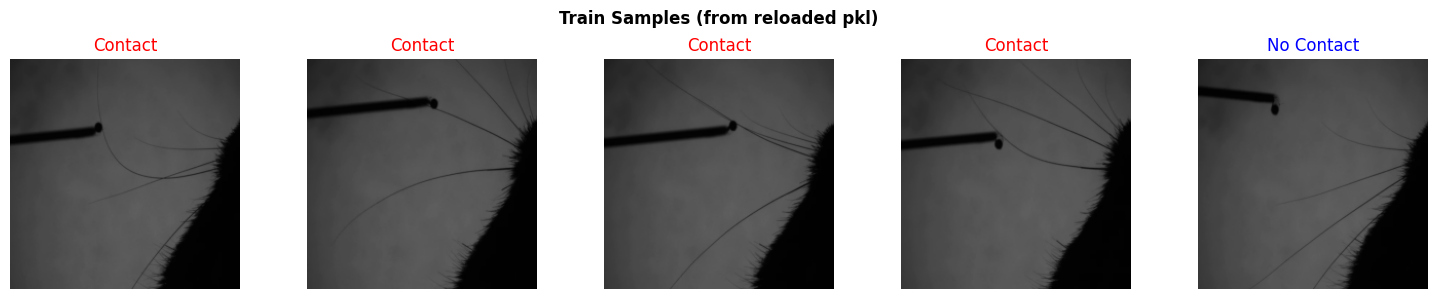


✅ Dataset creation complete!


In [10]:
# Show a few train samples as final confirmation
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(train_check["frames"][i])
    lbl = train_check["labels"][i]
    ax.set_title(f"{'Contact' if lbl else 'No Contact'}",
                 color="red" if lbl else "blue")
    ax.axis("off")
plt.suptitle("Train Samples (from reloaded pkl)", fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✅ Dataset creation complete!")